<a href="https://colab.research.google.com/github/ManuelRomero2025/CienciasdeDatos1/blob/main/CRISP_DM_estadistica_visualizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRISP-DM enfocado en Estadística y Visualización de Datos




# 1. Fundamentos teóricos de CRISP-DM

CRISP-DM significa **Cross-Industry Standard Process for Data Mining**.  
Es un marco metodológico que organiza los proyectos de analítica y ciencia de datos en seis fases:

1. Entendimiento del negocio  
2. Entendimiento de los datos  
3. Preparación de los datos  
4. Modelado  
5. Evaluación  
6. Despliegue  


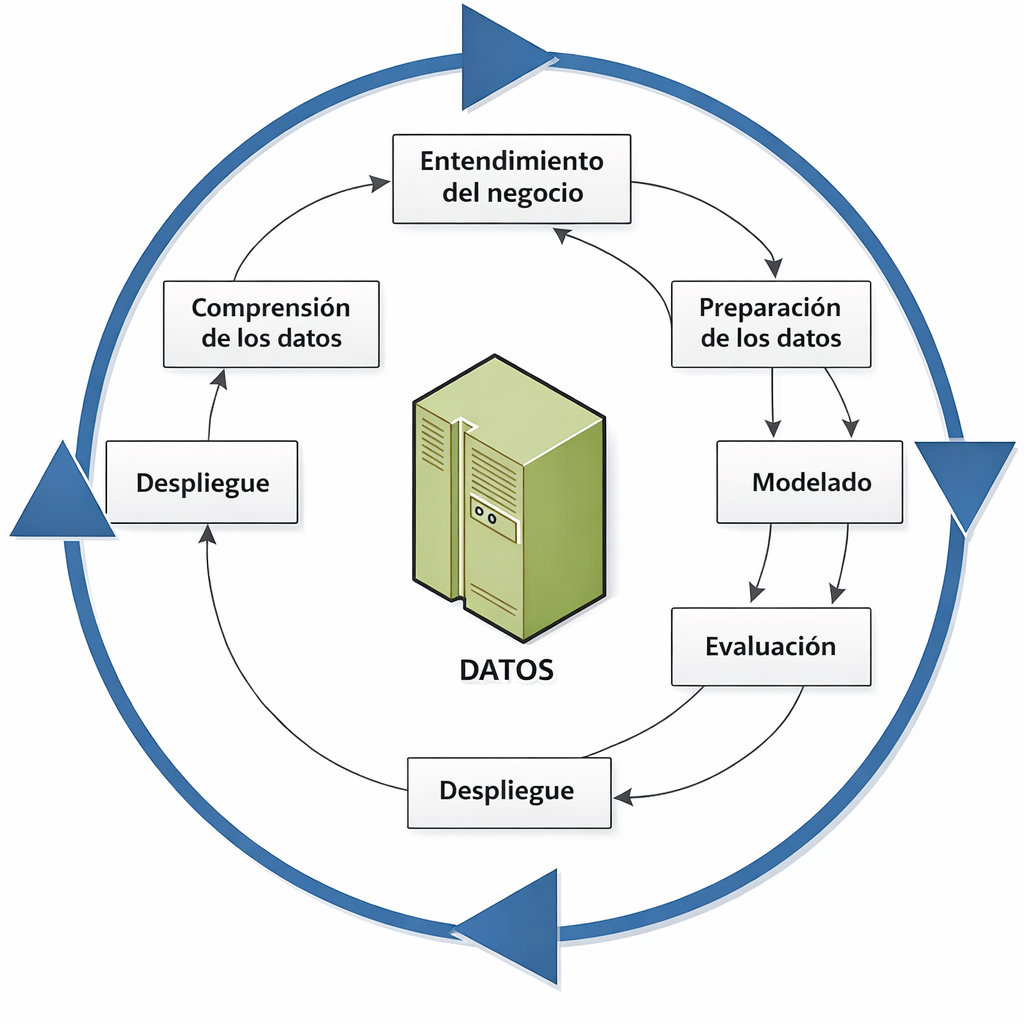


## Carácter iterativo
Aunque suele representarse como una secuencia, en la práctica el proceso es iterativo:
- si la calidad de los datos es baja, se regresa a preparación;
- si el modelo no responde al problema, se redefine el objetivo;
- si la evaluación muestra inestabilidad, se revisan variables y supuestos.

## Enfoque estadístico
La estadística permite:
- formular variables objetivo,
- describir distribuciones,
- estudiar correlaciones,
- detectar atípicos,
- validar modelos,
- interpretar resultados.

## Enfoque de visualización
La visualización permite:
- explorar patrones,
- detectar anomalías,
- comparar grupos,
- comunicar hallazgos.


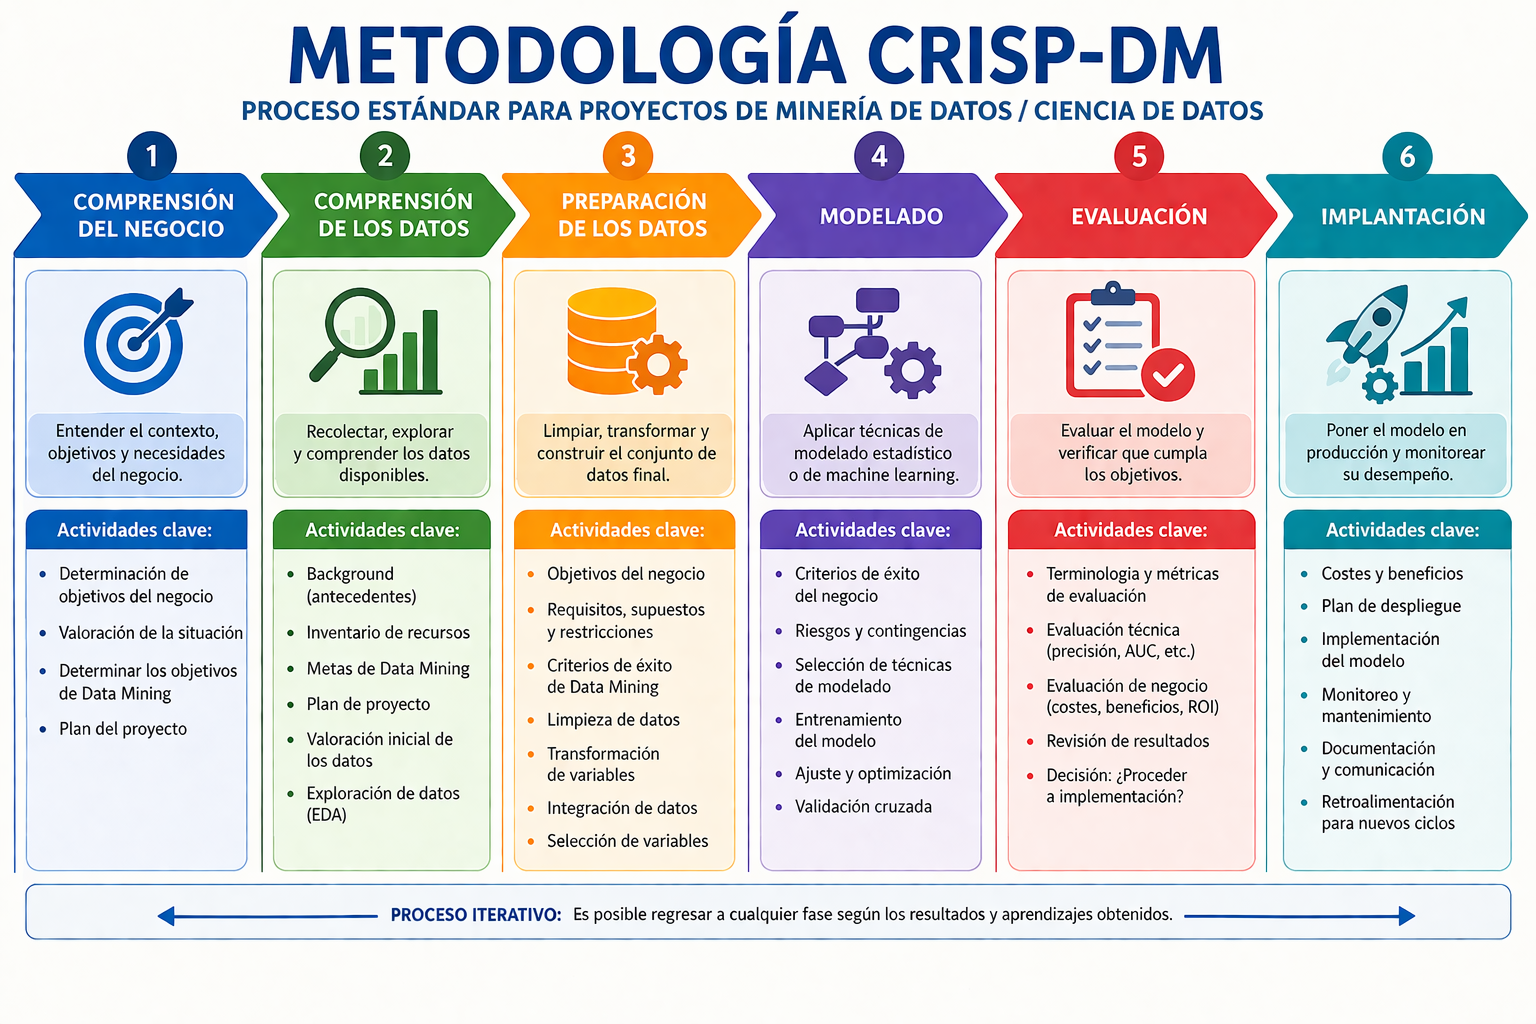

# 2. Relación entre CRISP-DM, estadística y visualización

| Fase CRISP-DM | Enfoque estadístico | Enfoque visual |
|---|---|---|
| Entendimiento del negocio | definición de KPI, objetivo y costo | diagramas, tableros |
| Entendimiento de los datos | descriptivos, distribuciones, correlaciones | histogramas, boxplots, heatmaps |
| Preparación de los datos | imputación, transformación, estandarización | comparación antes/después |
| Modelado | regresión, clasificación, ajuste | curvas ROC, importancia |
| Evaluación | métricas, calibración, intervalos | matriz de confusión, ROC, PR |
| Despliegue | monitoreo y estabilidad | dashboards y reportes |

En este cuaderno se usará por defecto el dataset `breast_cancer` de `scikit-learn`.  
Si OpenML está disponible, se intenta cargar `credit-g`.


# 3. Desarrollo matemático de la regresión logística

Sea:

$$
Y_i =
\begin{cases}
1, & \text{si el caso } i \text{ pertenece a la clase positiva} \\
0, & \text{si el caso } i \text{ pertenece a la clase negativa}
\end{cases}
$$

y sea $$\mathbf{x}_i = (x_{i1}, x_{i2}, \dots, x_{ip})$$ el vector de predictores.

El objetivo es estimar:

$$
P(Y_i = 1 \mid \mathbf{x}_i) = \pi_i
$$

## Modelo logístico

$$
\pi_i = \frac{1}{1 + e^{-\eta_i}}
$$

donde

$$
\eta_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip}
$$

Equivalentemente:

$$
\log\left(\frac{\pi_i}{1-\pi_i}\right)=\beta_0+\sum_{j=1}^{p}\beta_j x_{ij}
$$

## Odds Ratio

$$
OR_j = e^{\beta_j}
$$

## Función de costo orientada al negocio

$$
C = c_{FN} \cdot FN + c_{FP} \cdot FP
$$

Esto permite seleccionar umbrales que respondan al problema real.


In [ ]:
!pip -q install numpy pandas matplotlib seaborn scikit-learn statsmodels scipy plotly openml


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, brier_score_loss,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [ ]:
# Carga robusta del dataset
dataset_name = None

try:
    from sklearn.datasets import fetch_openml
    credit = fetch_openml(name="credit-g", version=1, as_frame=True)
    df = credit.frame.copy()
    dataset_name = "credit-g (OpenML)"
    target_col = "class"
    y = (df[target_col].astype(str).str.lower().str.contains("bad")).astype(int)
    X = df.drop(columns=[target_col]).copy()
except Exception:
    data = load_breast_cancer(as_frame=True)
    df = data.frame.copy()
    dataset_name = "breast_cancer (scikit-learn)"
    target_col = "target"
    y = df[target_col].astype(int)
    X = df.drop(columns=[target_col]).copy()

print("Dataset utilizado:", dataset_name)
print("Dimensiones:", df.shape)
df.head()


Dataset utilizado: credit-g (OpenML)
Dimensiones: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [ ]:
print(df.info())
display(df.head())

print("Distribución de la variable objetivo:")
display(pd.Series(y).value_counts().rename_axis("clase").reset_index(name="n"))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


Distribución de la variable objetivo:


,clase,n
0,0,700
1,1,300


# 4. Fase 1: Entendimiento del negocio

En una aplicación real, esta fase exige traducir una necesidad general a un objetivo analítico.

### Ejemplo general
Una organización desea identificar casos de alto riesgo para intervenir de manera temprana.

### KPI sugeridos
- AUC ≥ 0.75  
- Recall alto para la clase positiva  
- Brier Score bajo  
- Umbral ajustado al costo del error


# 5. Fase 2: Entendimiento de los datos

Se realiza el análisis exploratorio de datos (EDA) para estudiar:
- tipos de variables,
- valores faltantes,
- distribuciones,
- asimetrías,
- valores atípicos,
- asociaciones entre variables.


In [ ]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:", len(numeric_cols))
print("Variables categóricas:", len(categorical_cols))


Variables numéricas: 7
Variables categóricas: 13


In [ ]:
missing = X.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing) == 0:
    print("No hay valores faltantes en el dataset.")
else:
    display(missing.to_frame("n_missing"))


No hay valores faltantes en el dataset.


In [ ]:
if len(numeric_cols) > 0:
    desc = X[numeric_cols].describe().T
    desc["skew"] = X[numeric_cols].skew()
    desc["kurtosis"] = X[numeric_cols].kurtosis()
    display(desc.head(15))


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0,1.094184,0.919781
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0,1.949628,4.292590
installment_commitment,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0,-0.531348,-1.210473
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0,-0.272570,-1.381449
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0,1.020739,0.595780
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0,1.272576,1.604439
num_dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0,1.909445,1.649274


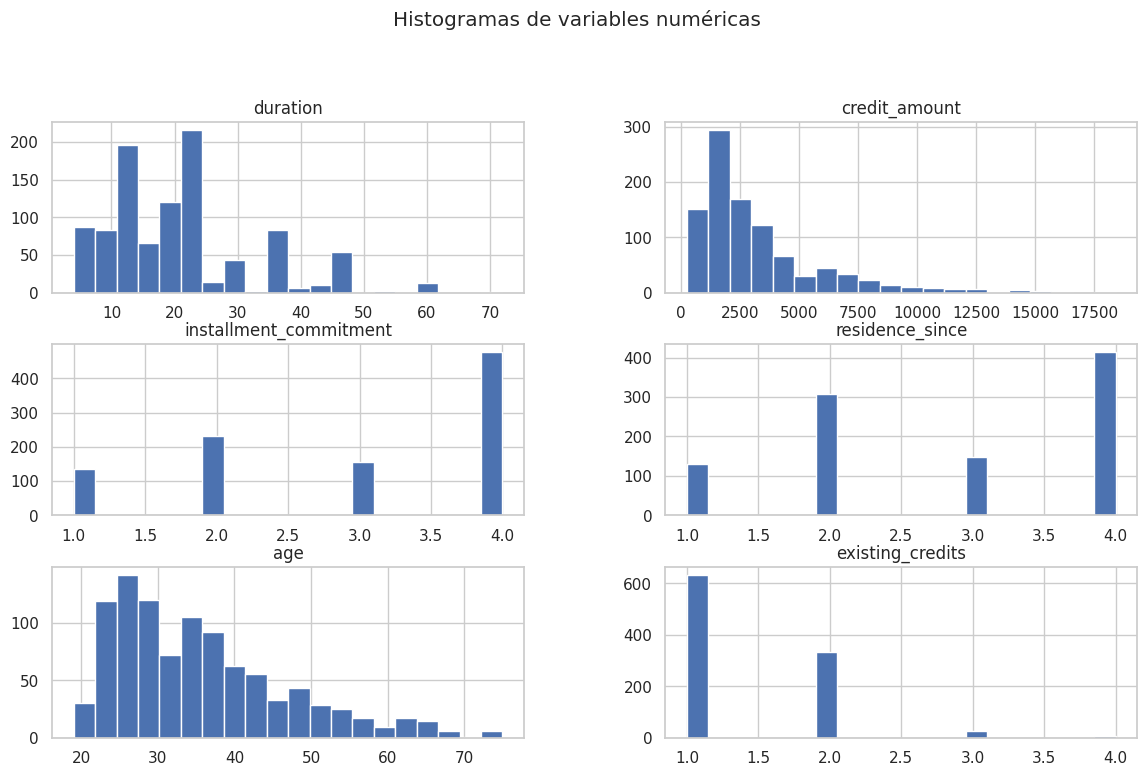

In [ ]:
plot_cols = numeric_cols[:6] if len(numeric_cols) >= 6 else numeric_cols

if len(plot_cols) > 0:
    X[plot_cols].hist(figsize=(14, 8), bins=20)
    plt.suptitle("Histogramas de variables numéricas", y=1.02)
    plt.show()


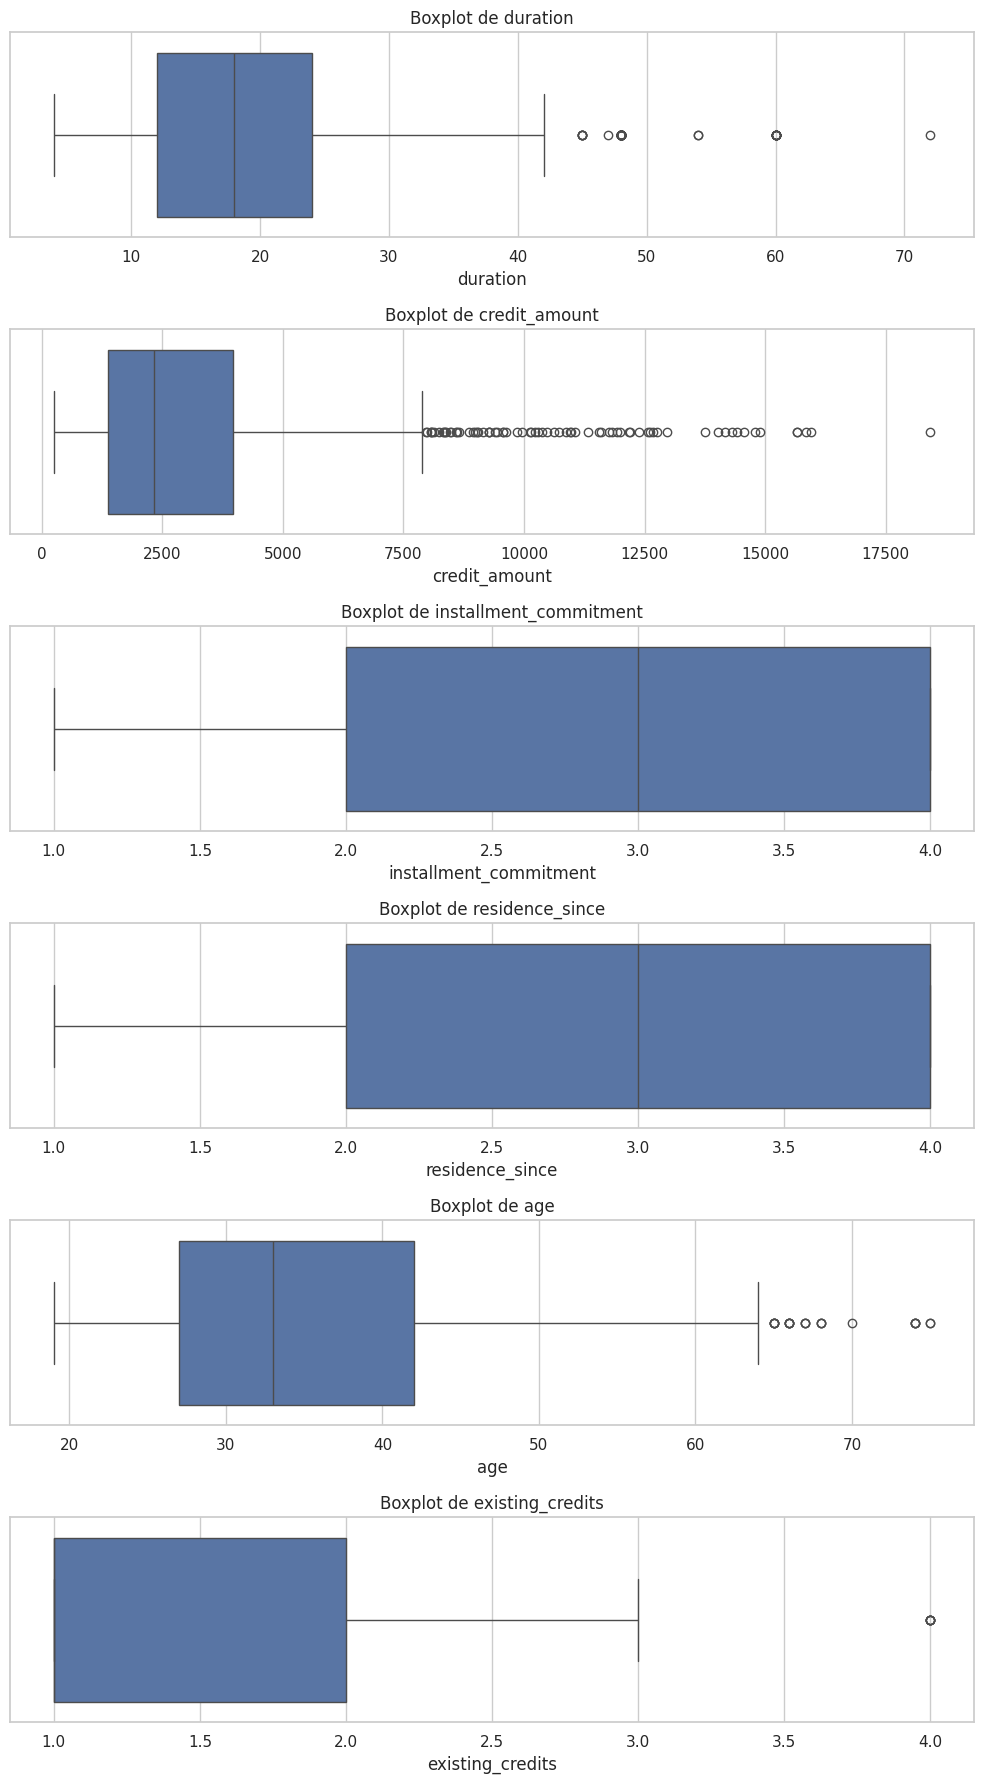

In [ ]:
if len(plot_cols) > 0:
    fig, axes = plt.subplots(nrows=len(plot_cols), ncols=1, figsize=(10, 3*len(plot_cols)))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        sns.boxplot(x=X[col], ax=ax)
        ax.set_title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()


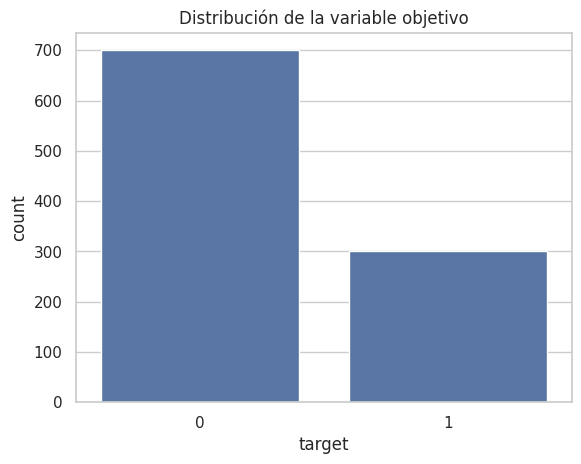

target
0    0.7
1    0.3
Name: proporción, dtype: float64


In [ ]:
target_df = pd.DataFrame({"target": y})
sns.countplot(x="target", data=target_df)
plt.title("Distribución de la variable objetivo")
plt.show()

print(target_df["target"].value_counts(normalize=True).rename("proporción"))


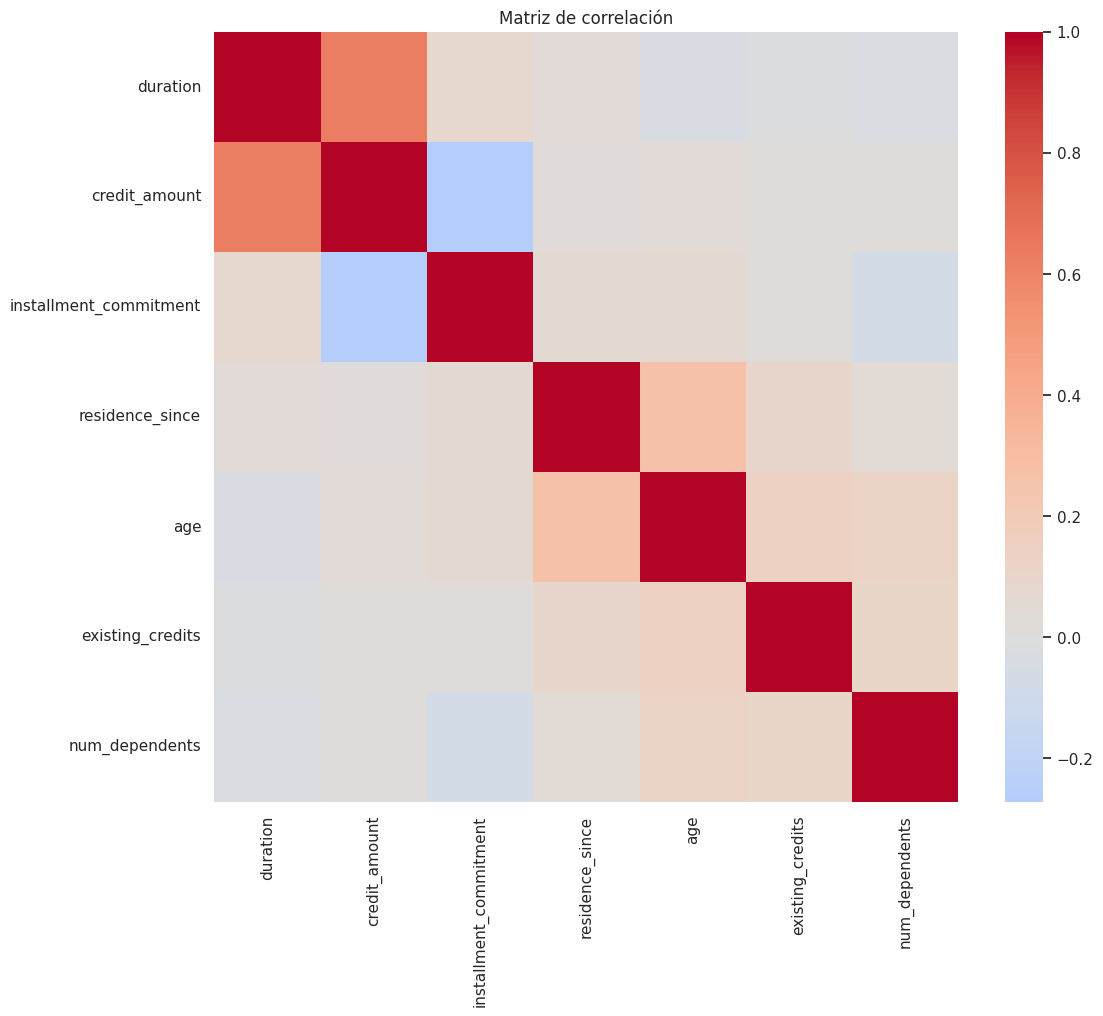

In [ ]:
# Check if X is defined
if 'X' not in globals():
    raise NameError(
        "Error: Variable 'X' (dataset) is not defined. "
        "Please ensure the data loading cell (hbWTSzDs13vm) has been executed to load the data."
    )

# Check if numeric_cols is defined, if not, re-derive it (from qHbd4cep13vp logic)
# np is imported in updtANFa13vl, but we ensure it's available for select_dtypes.
import numpy as np
if 'numeric_cols' not in globals() or 'categorical_cols' not in globals():
    print("Warning: 'numeric_cols' or 'categorical_cols' not found. Re-deriving numeric and categorical columns.")
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

if len(numeric_cols) >= 2:
    corr = X[numeric_cols].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matriz de correlación")
    plt.show()
else:
    print("No hay suficientes columnas numéricas para calcular la matriz de correlación.")

# 6. Fase 3: Preparación de los datos

Esta fase incluye:
- imputación de faltantes,
- codificación de categóricas,
- estandarización,
- ingeniería de variables,
- control de fuga de información.


In [ ]:
from sklearn.model_selection import train_test_split # Añadido para asegurar la importación

# Check if X and y are defined from the data loading step (cell hbWTSzDs13vm)
if 'X' not in globals() or 'y' not in globals():
    raise NameError(
        "Error: Variables 'X' and 'y' (dataset and target) are not defined. "
        "Please ensure the data loading cell (hbWTSzDs13vm) has been executed to load the data."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (800, 20) Test: (200, 20)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import numpy as np # Ensure numpy is imported for np.number, if not already global

# Check if X and y are defined from the data loading step (cell hbWTSzDs13vm)
if 'X' not in globals() or 'y' not in globals():
    raise NameError(
        "Error: Variables 'X' and 'y' (dataset and target) are not defined. "
        "Please ensure the data loading cell (hbWTSzDs13vm) has been executed to load the data."
    )

# Workaround: Ensure X_train, X_test, y_train, y_test are defined
# This makes the cell robust if the previous data splitting cell (DDI5y5kv13vs) was not run.
if 'X_train' not in globals() or 'y_train' not in globals():
    print("Warning: X_train or y_train not found. Performing train_test_split here as a fallback.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocesamiento definido.")

Preprocesamiento definido.


# 7. Fase 4: Modelado

Se comparan dos modelos:
1. Regresión logística  
2. Random Forest  

Esto permite discutir interpretabilidad frente a desempeño.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Check if preprocessor is defined
if 'preprocessor' not in globals():
    raise NameError(
        "Error: Variable 'preprocessor' is not defined. "
        "Please ensure the data preparation cell (_P9zhoPn13vs) has been executed to define the preprocessor."
    )

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced"
    ))
])

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "roc_auc": "roc_auc"
}

cv_log = cross_validate(log_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_rf  = cross_validate(rf_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

def summarize_cv(cv_results, model_name):
    return pd.DataFrame({
        "modelo": [model_name],
        "accuracy_mean": [cv_results["test_accuracy"].mean()],
        "accuracy_sd": [cv_results["test_accuracy"].std()],
        "recall_mean": [cv_results["test_recall"].mean()],
        "precision_mean": [cv_results["test_precision"].mean()],
        "roc_auc_mean": [cv_results["test_roc_auc"].mean()],
        "roc_auc_sd": [cv_results["test_roc_auc"].std()]
    })

cv_summary = pd.concat([
    summarize_cv(cv_log, "Regresión logística"),
    summarize_cv(cv_rf, "Random Forest")
], ignore_index=True)

display(cv_summary)


,modelo,accuracy_mean,accuracy_sd,recall_mean,precision_mean,roc_auc_mean,roc_auc_sd
0,Regresión logística,0.7450,0.038810,0.447222,0.603287,0.774554,0.044810
1,Random Forest,0.7575,0.027689,0.344444,0.694237,0.787512,0.033402


# 8. Fase 5: Evaluación

Se evaluarán los modelos con:
- accuracy,
- recall,
- precisión,
- F1,
- AUC,
- matriz de confusión,
- curva ROC,
- Brier score,
- calibración,
- intervalo bootstrap para AUC.


In [ ]:
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]


In [ ]:
def metric_table(y_true, y_pred, y_prob, model_name):
    return pd.DataFrame({
        "modelo": [model_name],
        "accuracy": [accuracy_score(y_true, y_pred)],
        "recall": [recall_score(y_true, y_pred)],
        "precision": [precision_score(y_true, y_pred)],
        "f1": [f1_score(y_true, y_pred)],
        "auc": [roc_auc_score(y_true, y_prob)],
        "brier": [brier_score_loss(y_true, y_prob)]
    })

test_metrics = pd.concat([
    metric_table(y_test, log_pred, log_prob, "Regresión logística"),
    metric_table(y_test, rf_pred, rf_prob, "Random Forest")
], ignore_index=True)

display(test_metrics)


,modelo,accuracy,recall,precision,f1,auc,brier
0,Regresión logística,0.780,0.533333,0.666667,0.592593,0.804048,0.154971
1,Random Forest,0.755,0.366667,0.666667,0.473118,0.805417,0.159927


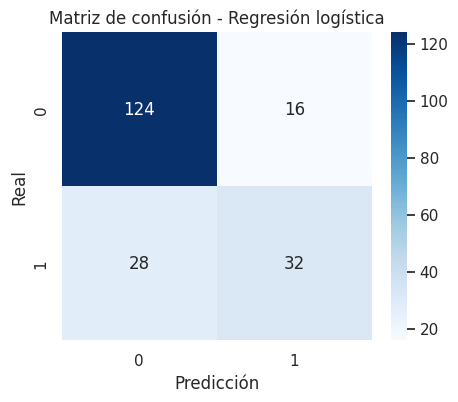

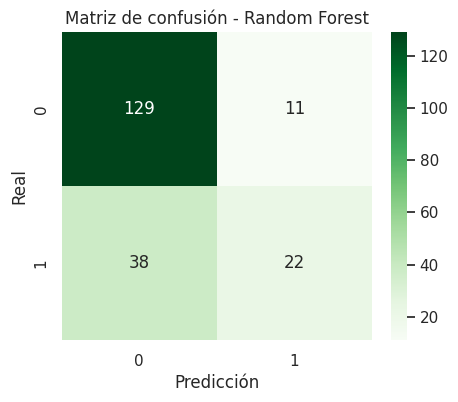

In [ ]:
cm_log = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


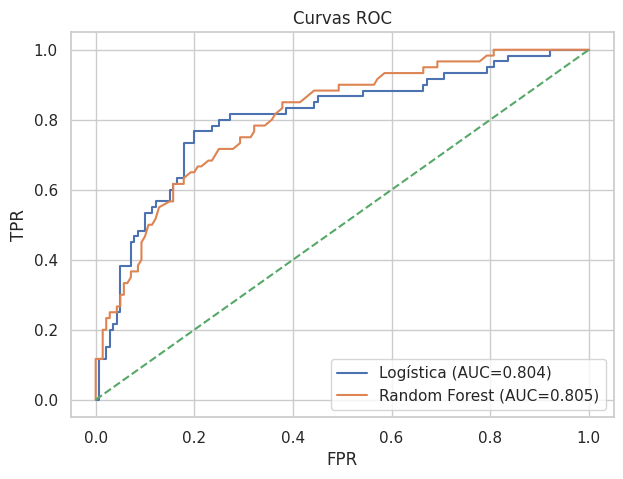

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr_log, tpr_log, label=f"Logística (AUC={roc_auc_score(y_test, log_prob):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curvas ROC")
plt.legend()
plt.show()


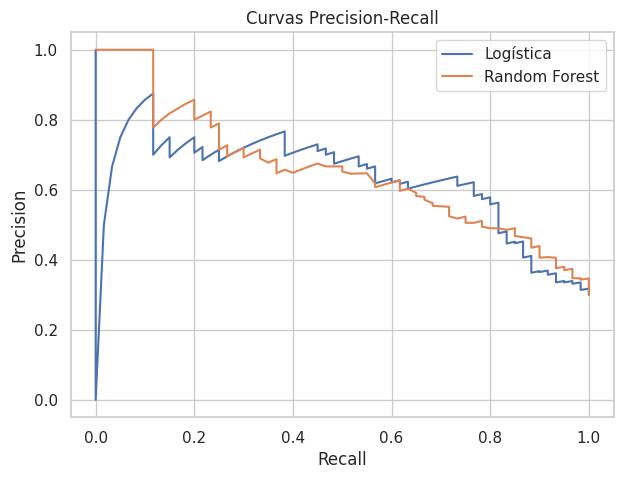

In [ ]:
precision_log, recall_log, _ = precision_recall_curve(y_test, log_prob)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))
plt.plot(recall_log, precision_log, label="Logística")
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall")
plt.legend()
plt.show()


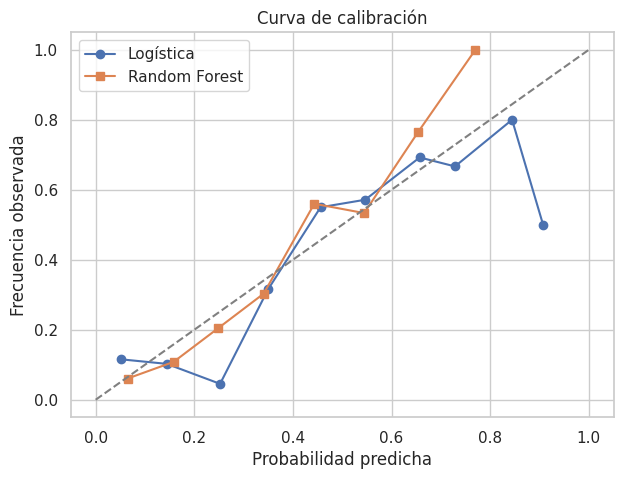

In [ ]:
prob_true_log, prob_pred_log = calibration_curve(y_test, log_prob, n_bins=10)
prob_true_rf, prob_pred_rf = calibration_curve(y_test, rf_prob, n_bins=10)

plt.figure(figsize=(7,5))
plt.plot(prob_pred_log, prob_true_log, marker="o", label="Logística")
plt.plot(prob_pred_rf, prob_true_rf, marker="s", label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.title("Curva de calibración")
plt.legend()
plt.show()


# 9. Selección de umbral por costo

Cuando el costo de un falso negativo es mayor que el de un falso positivo, puede elegirse un umbral distinto de 0.5.


In [ ]:
def bootstrap_auc_ci(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    aucs = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(aucs, [2.5, 97.5]), np.mean(aucs)

ci_log, auc_boot_log = bootstrap_auc_ci(y_test, log_prob)
ci_rf, auc_boot_rf = bootstrap_auc_ci(y_test, rf_prob)

bootstrap_tbl = pd.DataFrame({
    "modelo": ["Regresión logística", "Random Forest"],
    "auc_boot_mean": [auc_boot_log, auc_boot_rf],
    "ic_95_inf": [ci_log[0], ci_rf[0]],
    "ic_95_sup": [ci_log[1], ci_rf[1]]
})

display(bootstrap_tbl)


,modelo,auc_boot_mean,ic_95_inf,ic_95_sup
0,Regresión logística,0.803642,0.732331,0.869788
1,Random Forest,0.804932,0.740444,0.863225


# 10. Interpretación estadística de la regresión logística

Para interpretar coeficientes y odds ratios, se ajusta un modelo con `statsmodels` usando variables numéricas.


Mejor umbral: 0.3
Costo mínimo: 93


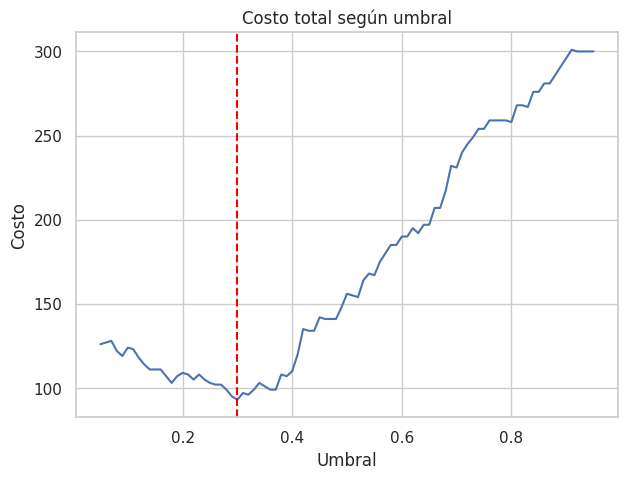

In [ ]:
c_fn = 5
c_fp = 1

thresholds = np.linspace(0.05, 0.95, 91)
costs = []

for t in thresholds:
    pred_t = (log_prob >= t).astype(int)
    fn = np.sum((pred_t == 0) & (y_test == 1))
    fp = np.sum((pred_t == 1) & (y_test == 0))
    cost = c_fn * fn + c_fp * fp
    costs.append(cost)

best_idx = int(np.argmin(costs))
best_t = thresholds[best_idx]
best_cost = costs[best_idx]

print("Mejor umbral:", round(best_t, 3))
print("Costo mínimo:", best_cost)

plt.figure(figsize=(7,5))
plt.plot(thresholds, costs)
plt.axvline(best_t, linestyle="--", color="red")
plt.title("Costo total según umbral")
plt.xlabel("Umbral")
plt.ylabel("Costo")
plt.show()


In [ ]:
if len(numeric_features) >= 2:
    X_num = X_train[numeric_features].copy()
    X_num = X_num.fillna(X_num.median())
    scaler_num = StandardScaler()
    X_num_scaled = pd.DataFrame(
        scaler_num.fit_transform(X_num),
        columns=numeric_features,
        index=X_num.index
    )

    X_sm = sm.add_constant(X_num_scaled)
    logit_sm = sm.Logit(y_train, X_sm).fit(disp=False)

    coef_table = pd.DataFrame({
        "coef": logit_sm.params,
        "odds_ratio": np.exp(logit_sm.params),
        "p_value": logit_sm.pvalues
    })
    display(coef_table.head(15))


,coef,odds_ratio,p_value
const,-0.894798,0.408690,1.221949e-28
duration,0.331637,1.393246,1.638024e-03
credit_amount,0.139245,1.149406,1.953951e-01
installment_commitment,0.212877,1.237232,1.780016e-02
residence_since,0.018847,1.019026,8.176316e-01
age,-0.148062,0.862377,8.916304e-02
existing_credits,-0.118336,0.888397,1.601005e-01
num_dependents,0.063042,1.065071,4.320443e-01


# 11. Fase 6: Despliegue

En un contexto académico, esta fase puede materializarse como:
- informe técnico,
- dashboard,
- sistema de scoring,
- presentación ejecutiva,
- monitoreo del modelo.

## Qué debería documentarse
- variable objetivo;
- pipeline reproducible;
- criterio de decisión;
- supuestos y limitaciones;
- plan de seguimiento;
- aspectos éticos y de gobernanza.


# 12. Tablas comparativas finales

## CRISP-DM tradicional vs enfoque estadístico-visual

| Aspecto | CRISP-DM tradicional | CRISP-DM con enfoque estadístico y visual |
|---|---|---|
| centro del proceso | modelo predictivo | comprensión integral de datos |
| papel de la estadística | apoyo al modelado | eje transversal |
| papel de la visualización | comunicación final | exploración, validación y comunicación |
| salida principal | modelo | interpretación y decisión |

## Comparación de modelos

| Aspecto | Regresión logística | Random Forest |
|---|---|---|
| interpretabilidad | alta | media-baja |
| manejo de no linealidad | limitado | bueno |
| sensibilidad a escala | sí | menor |
| explicación de coeficientes | directa | no directa |
| desempeño predictivo | bueno | frecuentemente superior |


# 13. Conclusiones

1. CRISP-DM ofrece una estructura metodológica sólida para proyectos analíticos.  
2. La estadística no debe restringirse al modelado; atraviesa todo el proceso.  
3. La visualización es clave para explorar, validar e interpretar.  
4. Un modelo no debe evaluarse solo por accuracy.  
5. La validación rigurosa mejora la calidad del análisis y la toma de decisiones.  

CRISP-DM, articulado con estadística y visualización, se convierte en una ruta de razonamiento analítico y no solo en una secuencia técnica.
